# 한글 밈 통역기

짤 이미지나 모르는 유행어를 입력하면 **뜻 · 유래 · 사용법 + 지금 써도 되는 밈인지(타이밍)** 알려주는 Agentic RAG 에이전트.

## 그래프 구조
```
START -> analyze_input -> retrieve_meme
                              |
                        [grade_documents]
              +---------------+---------------+
         yes  |          no & retry<2         | no & retry>=2
              v               v               v
        check_timing    rewrite_query     web_search
              |               +--> retrieve_meme  |
              +-------> generate_answer <---------+
                              |
                             END
```

## 데이터 출처
- [huggingface-KREW/KoCulture-Descriptions](https://huggingface.co/datasets/huggingface-KREW/KoCulture-Descriptions) (503건)
- 원자료: 나무위키 / 트렌드어워드
- **License: CC BY-NC-SA 4.0 (비상업 + 출처표기 + 동일조건 배포)**

In [ ]:
%pip install -Uqqq langchain langchain-openai langchain-pinecone langchain-tavily langgraph pandas pyarrow

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

---
## 1. 데이터 로드

In [2]:
import requests, os
import pandas as pd

DATA_URL = 'https://huggingface.co/datasets/huggingface-KREW/KoCulture-Descriptions/resolve/main/data/train-00000-of-00001.parquet'
DATA_PATH = 'koculture.parquet'

# 파일이 없을때만 다운로드
if not os.path.exists(DATA_PATH):
    res = requests.get(DATA_URL)
    res.raise_for_status()
    with open(DATA_PATH, 'wb') as f:
        f.write(res.content)
    print('다운로드 완료')

df = pd.read_parquet(DATA_PATH)
print(df.shape)      # (503, 5)
df.head(3)

다운로드 완료
(503, 5)


,title,content,date,category,source
0,원영적 사고,'원영적 사고'는 아이브 장원영의 초긍정적 사고방식에서 유래한 신조어입니다. 어떤 ...,2024.04.18,meme,trendaword
1,말아주다,'말아주다'는 2022년 말부터 등장해 2023년 초반부터 본격적으로 유행하기 시작...,2023.05.18,meme,trendaword
2,기습숭배,'기습숭배'는 갑작스럽게 누군가를 찬양하거나 숭배하는 행위를 일컫는 인터넷 밈입니다...,2024.06.20,meme,trendaword


In [3]:
# 컬럼 구조 파악
# title    : 밈/유행어 이름
# content  : 정의 + 유래 + 사용법 + 문화적 맥락  -> RAG 본문
# date     : 등장 시점 (YYYY.MM.DD 또는 YYYY 또는 빈 문자열)
# category : meme(대화 표현) / trend(유행 현상)
# source   : namuwiki / trendaword

print(df['category'].value_counts().to_dict())
print(df['source'].value_counts().to_dict())
print('content 길이 (최소/평균/최대):',
      df['content'].str.len().min(), int(df['content'].str.len().mean()), df['content'].str.len().max())

# date 결측 확인 : namuwiki 출처는 날짜가 비어있는 경우가 많다
print('date 비어있음:', (df['date'].str.strip() == '').sum(), '건')

{'meme': 347, 'trend': 156}
{'trendaword': 261, 'namuwiki': 242}
content 길이 (최소/평균/최대): 18 317 1580
date 비어있음: 149 건


### Document 변환


In [ ]:
from langchain_core.documents import Document

documents = []
for row in df.itertuples(index=False):
    # 밈 이름을 본문에 포함 -> "억텐이 뭐야?" 같은 이름 검색 될 확률 높이기
    page_content = f"[{row.title}]\n{row.content}"

    documents.append(Document(
        page_content=page_content,
        metadata={
            'title': row.title,
            'date': row.date,
            'category': row.category,
            'source': row.source,
            'year': row.date[:4] if row.date else '',   # 연도 필터링용
        }
    ))

print(len(documents))
print(documents[0].page_content[:200])
print(documents[0].metadata)

503
[원영적 사고]
'원영적 사고'는 아이브 장원영의 초긍정적 사고방식에서 유래한 신조어입니다. 어떤 부정적인 상황에서도 긍정적으로 해석하고 '럭키하다'고 생각하는 태도를 의미합니다.

이 용어는 장원영이 빵집에서 원하는 빵이 매진되었을 때, 이를 부정적으로 받아들이지 않고 "갓 나온 빵을 받을 수 있어서 럭키하다"고 반응한 일화에서 시작되었습니다. 주로 SN
{'title': '원영적 사고', 'date': '2024.04.18', 'category': 'meme', 'source': 'trendaword', 'year': '2024'}


---
## 2. Pinecone 인덱싱

In [5]:
from pinecone import Pinecone, ServerlessSpec

INDEX_NAME = 'korean-meme'

pc = Pinecone(api_key=os.environ['PINECONE_API_KEY'])

# 인덱스가 없으면 생성 (text-embedding-3-small = 1536차원)
if not pc.has_index(INDEX_NAME):
    pc.create_index(
        name=INDEX_NAME,
        dimension=1536,
        metric='cosine',
        spec=ServerlessSpec(cloud='aws', region='us-east-1')
    )
    print(f'{INDEX_NAME} 인덱스 생성 완료')
else:
    print(f'{INDEX_NAME} 인덱스가 이미 존재합니다')

korean-meme 인덱스 생성 완료


In [6]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')

vector_store = PineconeVectorStore(
    index_name=INDEX_NAME,
    embedding=embeddings,
)

In [7]:
# 배치 업로드 (503건이라 1~2분 소요)
# 주의: 이미 업로드했다면 이 셀은 다시 실행하지 말것 (중복 저장됨)
batch_size = 100

for i in range(0, len(documents), batch_size):
    batch_data = documents[i:i + batch_size]
    vector_store.add_documents(batch_data)
    print(f'index: {i} ~ {i + len(batch_data)}')

print('업로드 완료')

index: 0 ~ 100
index: 100 ~ 200
index: 200 ~ 300
index: 300 ~ 400
index: 400 ~ 500
index: 500 ~ 503
업로드 완료


In [8]:
# 인덱싱 검증
for doc in vector_store.similarity_search('원영적 사고', k=2):
    print(doc.metadata['title'], '|', doc.metadata['date'])
    print(doc.page_content[:120])
    print()

OO적 사고 | 2024.05.07
[OO적 사고]
'OO적 사고'는 연예인이나 유명인의 특정 발언이나 행동을 바탕으로 만들어진 사고방식을 일컫는 최근의 유행 표현입니다. 대표적으로 '원영적 사고'(긍정적 마인드), '동원적 사고'(어려운 상황에서 더

원영적 사고 | 2024.04.18
[원영적 사고]
'원영적 사고'는 아이브 장원영의 초긍정적 사고방식에서 유래한 신조어입니다. 어떤 부정적인 상황에서도 긍정적으로 해석하고 '럭키하다'고 생각하는 태도를 의미합니다.

이 용어는 장원영이 빵집에서 원하



---
## 3. 도구(Tool) 제작

In [9]:
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from typing import List, Optional, Literal, TypedDict, Annotated

llm = init_chat_model('gpt-5.4-mini', temperature=0)

### 3-1. 밈 검색 도구

In [10]:
@tool
def search_korean_meme(query: str) -> str:
    """한국 밈/유행어 아카이브에서 관련 항목을 검색하는 도구"""
    docs = vector_store.similarity_search(query, k=3)
    return '\n\n'.join(doc.page_content for doc in docs)


search_korean_meme.invoke('억텐')

'[억텐]\n\'억텐\'은 \'억지 텐션\'의 줄임말로, 실제로는 기분이나 텐션이 고조되지 않은 상태에서 상황에 맞춰 억지로 신나거나 흥분한 듯한 반응을 보여야 할 때 사용하는 신조어입니다. 주로 피곤하거나 의욕이 없는 상태에서 사회적 상황이나 분위기 때문에 어쩔 수 없이 텐션을 높여야 할 때 쓰입니다. 이와 대비되는 표현으로 진정으로 신나고 흥분된 상태를 의미하는 \'찐텐\'이 있습니다.\n\n예시 문장:\n- "아침부터 회식 자리라니, 오늘은 억텐 좀 해야겠다."\n- "피곤해 죽겠는데 친구 생일 파티에서 억텐 부리느라 더 힘들었어."\n\n[업토버]\n"업토버(Uptober)"는 10월의 암호화폐 시장, 특히 비트코인의 강세장을 지칭하는 신조어입니다. \'Up(상승)\'과 \'October(10월)\'의 합성어로, 역사적 데이터에 근거를 두고 있습니다. 2013년 이후 비트코인은 10월에 70%의 상승 마감률을 기록했으며, 코인데스크에 따르면 11월과 함께 암호화폐 시장의 최대 수익 창출 시기로 꼽힙니다. 이러한 통계적 경향으로 인해 암호화폐 투자자들 사이에서는 10월을 긍정적으로 기대하는 심리가 형성되어 있으며, 이는 각종 밈(meme)과 짤방 등 온라인 문화 콘텐츠로도 표현되고 있습니다.\n\n[하지만 빨랐죠]\n어벤져스: 엔드게임, 캡틴 아메리카: 윈터 솔져의 자막을 왜곡해 만든 밈이다. 일종의 거짓말은 하지 않는다에 해당하는 유머성 밈으로 주로 결과는 엉망이지만 하나만 콕 집어서 그 부분은 빠르게 넘긴 경우에 사용된다.'

### 3-2. 짤 이미지 분석 도구 (Vision)

In [11]:
def describe_meme_image(image_urls: List[str]) -> str:
    """짤 이미지에서 자막 텍스트와 상황을 '있는 그대로' 서술한다."""

    system_prompt = """
당신은 이미지에 있는 정보를 그대로 옮겨적는 기록자입니다.

[반드시 지킬 것]
1. 이미지에 적힌 한글/영어 텍스트를 **오탈자까지 그대로** 옮겨 적으세요.
2. 등장인물의 표정, 행동, 복장, 배경을 **객관적으로** 묘사하세요.
3. 알아볼 수 있는 인물/캐릭터/프로그램이 있다면 이름을 적으세요.

[절대 하지 말 것]
- 밈의 의미나 뜻을 추측하지 마세요.
- 유래를 지어내지 마세요.
- "~인 것 같다", "~를 의미한다" 같은 해석을 하지 마세요.

[출력 형식]
자막: (이미지 속 텍스트 그대로)
장면: (객관적 묘사 2~3문장)
"""

    content = [{'type': 'text', 'text': system_prompt}]
    for url in image_urls:
        content.append({'type': 'image_url', 'image_url': {'url': url}})

    response = llm.invoke([HumanMessage(content=content)])
    return response.content

In [12]:
# 로컬 이미지 파일을 쓸 경우를 위한 헬퍼 (base64 data URI 변환)
import base64, mimetypes

def image_to_data_uri(path: str) -> str:
    mime = mimetypes.guess_type(path)[0] or 'image/jpeg'
    with open(path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()
    return f'data:{mime};base64,{b64}'

### 3-3. 웹검색 폴백 도구

아카이브가 503건뿐이라 최신 밈은 Tavily를 사용

In [13]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)


def search_meme_on_web(query: str) -> str:
    """웹에서 밈 정보를 검색 (아카이브에 없을 때의 폴백)"""
    result = tavily_tool.invoke({'query': f'{query} 밈 뜻 유래'})

    docs = []
    for r in result.get('results', []):
        docs.append(f"[{r.get('title')}]\n{r.get('content')}\n출처: {r.get('url')}")
    return '\n\n'.join(docs)

---
## 4. State 정의

`retry_count`는 rewrite 루프의 **무한루프 방지 장치**,
`meme_date`는 이 프로젝트 고유의 **타이밍 판정**에 쓰인다.

In [14]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage


class MemeState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]  # 대화 누적
    image_urls: Optional[List[str]]     # 입력 짤 이미지
    query: Optional[str]                # 검색용 텍스트 (vision 서술 or 사용자 질문)
    context: Optional[str]              # 검색된 밈 설명 본문
    meme_title: Optional[str]           # 찾아낸 밈 이름
    meme_date: Optional[str]            # 유행 시기 -> 신선도 판정용
    timing: Optional[str]               # 타이밍 판정 결과
    retry_count: int                    # rewrite 재시도 횟수
    source_layer: Optional[str]         # 'local' | 'web' (어디서 찾았는지)

---
## 5. 노드 구현

### 5-1. analyze_input : 입력 -> 검색 쿼리

In [15]:
def analyze_input(state: MemeState):
    """이미지가 있으면 Vision으로 서술, 없으면 사용자 질문을 그대로 검색 쿼리로 사용"""
    image_urls = state.get('image_urls')
    user_text = state['messages'][-1].content

    if image_urls:
        description = describe_meme_image(image_urls)
        # 짤 서술 + 사용자 질문을 합쳐 검색 쿼리 구성
        query = f'{description}\n{user_text}'.strip()
        print(f'[analyze_input] 이미지 분석\n{description}\n')
    else:
        query = user_text
        print(f'[analyze_input] 텍스트 입력: {query}')

    return {'query': query, 'retry_count': 0}

### 5-2. retrieve_meme : 아카이브 검색

In [16]:
def retrieve_meme(state: MemeState):
    """벡터DB에서 밈 후보를 검색하고 메타데이터를 State에 저장"""
    docs = vector_store.similarity_search(state['query'], k=3)

    if not docs:
        return {'context': '', 'source_layer': 'local'}

    top = docs[0]
    context = '\n\n'.join(doc.page_content for doc in docs)

    print(f"[retrieve_meme] 1순위 후보: {top.metadata['title']} ({top.metadata['date'] or '날짜없음'})")

    return {
        'context': context,
        'meme_title': top.metadata['title'],
        'meme_date': top.metadata['date'],
        'source_layer': 'local',
    }

### 5-3. grade_documents : 관련성 채점 (조건부 엣지)

01_agentic_rag의 패턴을 그대로 쓰되, **`retry_count`로 루프를 끊는 분기**를 추가했다.

In [17]:
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate

GRADE_PROMPT = (
    "당신은 검색된 밈 설명이 사용자의 질문에 답할 수 있는지 판단하는 평가자입니다.\n\n"
    "검색된 밈 설명:\n{context}\n\n"
    "사용자 입력:\n{question}\n\n"
    "사용자가 궁금해하는 그 밈/표현이 검색 결과에 실제로 포함되어 있으면 'yes',\n"
    "전혀 다른 밈이 검색되었거나 관련이 없으면 'no'로 답하세요.\n"
    "단순히 주제가 비슷한 정도라면 'no'입니다."
)


class GradeDocuments(BaseModel):
    binary_score: str = Field(description="관련이 있으면 'yes', 없으면 'no'")


grader_model = init_chat_model('gpt-5.4-mini', temperature=0)

MAX_RETRY = 2


def grade_documents(state: MemeState) -> Literal['check_timing', 'rewrite_query', 'web_search']:
    """검색 결과의 관련성을 채점하여 다음 노드를 결정"""
    if not state.get('context'):
        return 'web_search'

    prompt = PromptTemplate.from_template(GRADE_PROMPT)
    chain = prompt | grader_model.with_structured_output(GradeDocuments)
    response = chain.invoke({'question': state['query'], 'context': state['context']})

    score = response.binary_score.strip().lower()
    retry = state.get('retry_count', 0)
    print(f'[grade_documents] 판정={score}, retry={retry}')

    if score == 'yes':
        return 'check_timing'

    # 관련 없음 -> 재작성 or 웹검색
    if retry < MAX_RETRY:
        return 'rewrite_query'
    return 'web_search'

### 5-4. rewrite_query : 검색어 재작성

In [18]:
REWRITE_PROMPT = """
아래 입력에서 **밈/유행어로 보이는 핵심 표현만** 뽑아 검색어로 만드세요.

[규칙]
- 설명 문장이 아니라 검색 키워드로 만드세요.
- 조사, 존댓말, 물음표는 제거하세요.
- 짤 서술이라면 자막에 있는 표현을 우선하세요.
- 검색어만 출력하고 다른 말은 하지 마세요.

[이전 검색어]
{query}

[예시]
"아들이 카톡에 어쩔티비라고 보냈는데 무슨 뜻이야?" -> 어쩔티비
"자막: 갑자기 분위기 싸해짐 / 장면: 남성이 정색하는 표정" -> 갑분싸
"""


def rewrite_query(state: MemeState):
    """검색 실패시 쿼리를 키워드 중심으로 재작성"""
    prompt = PromptTemplate.from_template(REWRITE_PROMPT)
    chain = prompt | llm

    new_query = chain.invoke({'query': state['query']}).content.strip()
    retry = state.get('retry_count', 0) + 1

    print(f'[rewrite_query] 재작성 -> {new_query} (retry={retry})')

    return {'query': new_query, 'retry_count': retry}

### 5-5. web_search : Tavily 폴백

In [19]:
def web_search(state: MemeState):
    """아카이브에서 못 찾았을 때 웹에서 검색"""
    print(f"[web_search] 아카이브 실패 -> 웹검색: {state['query']}")

    context = search_meme_on_web(state['query'])

    return {
        'context': context,
        'source_layer': 'web',
        'meme_date': '',          # 웹 결과는 시기를 알 수 없음
        'timing': '시기 정보 없음 (웹 검색 결과)',
    }

### 5-6. check_timing : 타이밍 판정 ⭐

**이 프로젝트만의 노드.** 밈은 타이밍이 곧 의미라서,
"뜻"만 알려주는 것보다 "지금 써도 되는지"를 알려주는 게 실질적인 가치다.

데이터셋의 `date`는 `YYYY.MM.DD` / `YYYY` / 빈 문자열 세 가지 형태가 섞여 있어 모두 처리한다.
(실측: 전체날짜 261건 / 연도만 93건 / 비어있음 149건)

In [20]:
from datetime import datetime


def check_timing(state: MemeState):
    """밈의 등장 시기와 현재를 비교해 신선도를 판정"""
    date_str = (state.get('meme_date') or '').strip()

    if not date_str:
        timing = '시기 불명 - 데이터에 등장 시점이 기록되어 있지 않음'
    else:
        year = int(date_str[:4])
        years_ago = datetime.now().year - year

        if years_ago <= 1:
            timing = f'현재 진행형 ({year}년 등장) - 지금 써도 자연스러움'
        elif years_ago <= 3:
            timing = f'살짝 지남 ({year}년 등장, {years_ago}년 경과) - 다들 알아듣지만 새롭진 않음'
        else:
            timing = f'올드함 ({year}년 등장, {years_ago}년 경과) - 지금 쓰면 옛날 사람 취급받을 수 있음'

    print(f'[check_timing] {timing}')
    return {'timing': timing}

### 5-7. generate_answer : 최종 통역

In [21]:
ANSWER_PROMPT = """
당신은 인터넷 밈을 모르는 사람에게 친절하게 설명해주는 '밈 통역사'입니다.
아래 자료만 근거로 사용해 답변하세요. 자료에 없는 내용은 지어내지 마세요.

## 검색된 자료 ##
{context}

## 타이밍 판정 ##
{timing}

## 사용자 입력 ##
{query}

## 답변 형식 ##
**뜻**: 한 문장으로 간단명료하게

**유래**: 어디서 시작됐는지 2~3문장

**이렇게 씁니다**: 실제 사용 예시 1~2개

**지금 써도 될까?**: 위 타이밍 판정을 자연스러운 문장으로 풀어서 설명

**주의**: 쓰면 안 되는 상황이 있다면 알려주기 (회사, 윗사람 앞 등). 없으면 생략.

자료가 사용자 질문과 명백히 무관하다면, 솔직하게 "찾지 못했다"고 답하세요.
"""


def generate_answer(state: MemeState):
    """검색 결과 + 타이밍 판정을 종합해 최종 답변 생성"""
    prompt = PromptTemplate.from_template(ANSWER_PROMPT)
    chain = prompt | llm

    response = chain.invoke({
        'context': state.get('context') or '(검색 결과 없음)',
        'timing': state.get('timing') or '시기 정보 없음',
        'query': state['query'],
    })

    # 출처 표기
    layer = state.get('source_layer')
    footer = '\n\n---\n📚 출처: 로컬 밈 아카이브' if layer == 'local' else '\n\n---\n🌐 출처: 웹 검색'
    response.content = response.content + footer

    return {'messages': [response]}

---
## 6. 그래프 조립

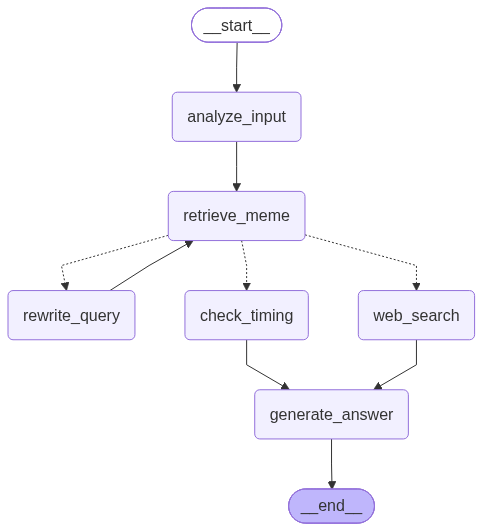

In [29]:
builder = StateGraph(MemeState)

# 노드 등록
builder.add_node('analyze_input', analyze_input)
builder.add_node('retrieve_meme', retrieve_meme)
builder.add_node('rewrite_query', rewrite_query)
builder.add_node('web_search', web_search)
builder.add_node('check_timing', check_timing)
builder.add_node('generate_answer', generate_answer)

# 엣지 연결
builder.add_edge(START, 'analyze_input')
builder.add_edge('analyze_input', 'retrieve_meme')

# 조건부 엣지 : 채점 결과에 따라 3방향 분기
builder.add_conditional_edges(
    'retrieve_meme',
    grade_documents,
    {
        'check_timing': 'check_timing',
        'rewrite_query': 'rewrite_query',
        'web_search': 'web_search',
    }
)

builder.add_edge('rewrite_query', 'retrieve_meme')   # 재작성 후 다시 검색 (루프)
builder.add_edge('web_search', 'generate_answer')
builder.add_edge('check_timing', 'generate_answer')
builder.add_edge('generate_answer', END)

graph = builder.compile()
graph

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

---
## 7. 테스트

### 시나리오 1 : 아카이브에 있는 밈 (1회 검색 성공)

In [23]:
def ask(text, image_urls=None):
    """에이전트 실행 헬퍼"""
    result = graph.invoke({
        'messages': [('human', text)],
        'image_urls': image_urls,
        'retry_count': 0,
    })
    print('\n' + '=' * 60)
    print(result['messages'][-1].content)
    return result


result = ask('억텐이 무슨 뜻이야?')

[analyze_input] 텍스트 입력: 억텐이 무슨 뜻이야?
[retrieve_meme] 1순위 후보: 억텐 (2021.04.28)
[grade_documents] 판정=yes, retry=0
[check_timing] 올드함 (2021년 등장, 5년 경과) - 지금 쓰면 옛날 사람 취급받을 수 있음

**뜻**: ‘억지 텐션’의 줄임말로, 실제 기분은 안 좋은데 상황 때문에 일부러 신나 보이게 반응하는 걸 말해요.

**유래**: 자료에 따르면 ‘억텐’은 ‘억지 텐션’에서 온 신조어예요. 피곤하거나 의욕이 없어도 사회적인 분위기나 상황 때문에 억지로 텐션을 올려야 할 때 쓰입니다. 반대말처럼 진짜 신나고 흥분된 상태는 ‘찐텐’이라고 해요.

**이렇게 씁니다**:  
- “아침부터 회식 자리라니, 오늘은 억텐 좀 해야겠다.”  
- “피곤해 죽겠는데 친구 생일 파티에서 억텐 부리느라 더 힘들었어.”

**지금 써도 될까?**: 자료의 타이밍 판정상 2021년 등장 이후 5년이 지나서, 지금 쓰면 조금 옛날 표현처럼 느껴질 수 있어요. 너무 자연스럽게 쓰는 사람도 있겠지만, 경우에 따라선 옛날 사람 취급을 받을 수도 있습니다.

**주의**: 회사나 윗사람 앞에서는 너무 캐주얼하게 들릴 수 있어 조심하는 게 좋아요.

---
📚 출처: 로컬 밈 아카이브


In [24]:
# 타이밍 판정 확인 : 2022년 유행 밈
result = ask('중꺾마 지금 써도 돼?')

[analyze_input] 텍스트 입력: 중꺾마 지금 써도 돼?
[retrieve_meme] 1순위 후보: 중꺾마 (2022.12.06)
[grade_documents] 판정=yes, retry=0
[check_timing] 올드함 (2022년 등장, 4년 경과) - 지금 쓰면 옛날 사람 취급받을 수 있음

**뜻**: ‘중꺾마’는 **“중요한 것은 꺾이지 않는 마음”**의 줄임말로, 포기하지 않는 의지를 뜻합니다.

**유래**: 2022년 10월 리그 오브 레전드 월드 챔피언십에서 DRX 팀의 김현규 선수 인터뷰를 계기로 처음 퍼졌습니다. 이후 2022 카타르 월드컵에서 한국 축구 대표팀의 16강 진출과 함께 전국적으로 유행하게 됐습니다.

**이렇게 씁니다**:  
- “이번 시험 망한 것 같아도 **중꺾마**로 끝까지 해보자.”  
- “경기 아직 안 끝났어, **중꺾마** 정신으로 가자.”

**지금 써도 될까?**: 자료 기준으로는 2022년을 대표하는 유행어라서 지금 쓰면 다소 옛날 느낌이 날 수 있습니다. 즉, 의미는 통하지만 최신 유행어처럼 느껴지지는 않을 수 있어요.

**주의**: 특별히 쓰면 안 되는 상황이 따로 적혀 있지는 않지만, 너무 격식을 차려야 하는 자리에서는 조금 가볍게 들릴 수 있습니다.

---
📚 출처: 로컬 밈 아카이브


### 시나리오 2 : rewrite 루프 확인

문장이 길어서 1차 검색이 빗나가는 케이스. `[rewrite_query]` 로그가 찍히는지 확인.

In [25]:
result = ask('아들이 카톡에 원영적 사고 어쩌구 하면서 보냈는데 이게 도대체 무슨 소리야?')

[analyze_input] 텍스트 입력: 아들이 카톡에 원영적 사고 어쩌구 하면서 보냈는데 이게 도대체 무슨 소리야?
[retrieve_meme] 1순위 후보: 원영적 사고 (2024.04.18)
[grade_documents] 판정=yes, retry=0
[check_timing] 살짝 지남 (2024년 등장, 2년 경과) - 다들 알아듣지만 새롭진 않음

**뜻**: 부정적인 상황도 일부러 긍정적으로 받아들이며 “이것도 럭키한 일”이라고 말하는 태도입니다.

**유래**: 아이브 장원영이 빵집에서 원하는 빵이 매진됐을 때도 “갓 나온 빵을 받을 수 있어서 럭키하다”고 반응한 일화에서 시작됐습니다. 이 표현은 SNS, 특히 X(구 트위터)에서 퍼졌고, “하지만 원영적 사고를 하면~”처럼 말한 뒤 “럭키OO이잖아”로 마무리하는 식으로 많이 씁니다.

**이렇게 씁니다**:  
- “시험 망친 것 같아도 원영적 사고를 하면, 오답을 미리 알아낸 거라 럭키잖아.”  
- “비 와서 망했다 싶었는데 원영적 사고로 보면, 운치 있는 빗소리 들을 수 있으니 럭키비키잖아.”

**지금 써도 될까?**: 2024년에 나온 뒤 2년쯤 지나서, 다들 대체로 알아듣는 편이지만 아주 새롭거나 최신 유행은 아닙니다.

**주의**: 가볍게 농담하는 분위기에는 괜찮지만, 진지하게 상황을 다뤄야 하는 자리에서는 너무 가볍게 들릴 수 있어 조심하는 게 좋습니다.

---
📚 출처: 로컬 밈 아카이브


### 시나리오 3 : 웹 폴백 확인

아카이브(2025년까지)에 없는 최신 밈 -> rewrite 2회 실패 -> `[web_search]` 도달 확인.

In [26]:
result = ask('요즘 유행하는 밈 중에 하나 알려줘봐, 완전 최신으로')
print()
print('source_layer:', result.get('source_layer'), '/ retry_count:', result.get('retry_count'))

[analyze_input] 텍스트 입력: 요즘 유행하는 밈 중에 하나 알려줘봐, 완전 최신으로
[retrieve_meme] 1순위 후보: 꽁꽁 얼어붙은 한강 위로 고양이가 걸어다닙니다 (2024)
[grade_documents] 판정=yes, retry=0
[check_timing] 살짝 지남 (2024년 등장, 2년 경과) - 다들 알아듣지만 새롭진 않음

**뜻**: “꽁꽁 얼어붙은 한강 위로 고양이가 걸어다닙니다”는 뜻밖에 귀엽고 리듬감 있는 뉴스 문장을 재미있게 따라 하거나 패러디할 때 쓰는 밈입니다.

**유래**: 2021년 12월 27일 MBN 뉴스 7의 한파 관련 보도에서, 얼어붙은 뚝섬한강공원 위를 지나가던 고양이 모습이 우연히 촬영되어 함께 방송된 장면에서 시작됐습니다. 기사 내용과 화면이 정직하게 맞아떨어지는 데다, 딱딱한 뉴스 속에서 보기 힘든 귀여운 장면과 나레이션의 묘한 리듬감이 겹치면서 2024년에 크게 다시 떠올랐습니다.

**이렇게 씁니다**:  
- 친구가 귀엽고 엉뚱한 장면을 보여줄 때: “이거 완전 꽁꽁 얼어붙은 한강 위로 고양이가 걸어다닙니다 같네.”  
- 영상이나 상황을 살짝 장난스럽게 패러디할 때: “오늘 분위기, 꽁냥이 감성인데?”

**지금 써도 될까?**:  
네, 아직은 다들 알아듣는 편이라 써도 괜찮습니다. 다만 2024년에 크게 유행한 뒤 시간이 조금 지난 상태라, 완전 새 밈이라기보다는 이미 익숙한 유행어에 가깝습니다.

**주의**:  
가벼운 농담용이라 너무 진지한 자리나 공식적인 대화에서는 덜 어울릴 수 있습니다.

---
📚 출처: 로컬 밈 아카이브

source_layer: local / retry_count: 0


### 시나리오 4 : 짤 이미지 입력

⚠️ **아래 이미지 경로/URL을 직접 준비한 짤로 교체하세요.**
- 로컬 파일이면 `image_to_data_uri('경로.jpg')` 사용
- 자막이 박힌 한국 짤이 가장 잘 동작함

In [27]:
# 로컬 파일 예시
# result = ask('이 짤 무슨 뜻이야?', image_urls=[image_to_data_uri('memes/test1.jpg')])

# URL 예시
result = ask(
    '이 짤 무슨 뜻이야?',
    image_urls=['https://s3.ap-northeast-2.amazonaws.com/univ-careet/FileData/Picture/202608/5ae9a6dc-5096-44d1-81e4-457ed89fb5a3_770x426.png']
)

[analyze_input] 이미지 분석
자막: 모르는 개 산책 / 🌲🌲🌲 / 노랗이 숲으로 돌아갔다 ↩️ / 다이스키 입니다 / 눈 가리고 야옹 / 마지막 / 고마워

장면: 흰 배경 위에 큰 검은 한글 문구와 이모지들이 배치되어 있습니다. 왼쪽에는 갈색 개 이모지와 붉은 물음표, 가운데에는 얼굴을 가리는 고양이 이모지가 있으며, 오른쪽에는 금발 여성의 얼굴 사진이 있고 손으로 작은 물건을 들고 있는 자세입니다. 말풍선 안에는 “마지 고마워”가 적혀 있습니다.

[retrieve_meme] 1순위 후보: 뿌잉뿌잉 (날짜없음)
[grade_documents] 판정=no, retry=0
[rewrite_query] 재작성 -> 눈 가리고 야옹 / 다이스키 입니다 / 고마워 (retry=1)
[retrieve_meme] 1순위 후보: 빌려온 고양이 같이 (2025.01.23)
[grade_documents] 판정=no, retry=1
[rewrite_query] 재작성 -> 눈 가리고 야옹 / 다이스키 / 고마워 (retry=2)
[retrieve_meme] 1순위 후보: 듀아아아 (2025.01.14)
[grade_documents] 판정=no, retry=2
[web_search] 아카이브 실패 -> 웹검색: 눈 가리고 야옹 / 다이스키 / 고마워

자료에서 확인되는 건 **“눈 가리고 아웅한다”**이고, 사용자가 적은 **“눈 가리고 야옹 / 다이스키 / 고마워”**와 직접 연결되는 밈 정보는 **찾지 못했습니다.**  
그래서 아래는 자료에 근거해 **“눈 가리고 아웅한다”**만 설명합니다.

**뜻**: 겉으로는 속이는 척하지만 실제로는 금방 들통날 만큼 어설프게 처리하는 것을 말합니다.

**유래**: 어린아이에게 얼굴을 손으로 가렸다가 치우며 “아옹!(까꿍)” 하는 놀이인 **아옹놀이**에서 나온 속담입니다. 그래서 뭔가를 대충 숨기거나, 모르는 척하면서 사실을 가리려는 행동을 비유할 때 씁니다.

**이렇게 씁니다**:  
- “그렇게 대충 얼버무리

### 시나리오 5 : 무한루프 방지 확인

밈과 전혀 무관한 질문. `retry_count`가 MAX_RETRY(2)에서 끊기고 웹검색으로 빠지는지 확인.

In [28]:
result = ask('오늘 점심 뭐 먹지?')
print()
print('retry_count:', result.get('retry_count'), '(MAX_RETRY=2 를 넘지 않아야 함)')

[analyze_input] 텍스트 입력: 오늘 점심 뭐 먹지?
[retrieve_meme] 1순위 후보: 점메추 (2021.04.20)
[grade_documents] 판정=yes, retry=0
[check_timing] 올드함 (2021년 등장, 5년 경과) - 지금 쓰면 옛날 사람 취급받을 수 있음

**뜻**: `점메추`는 “점심 메뉴 추천”의 줄임말로, 점심에 뭘 먹을지 추천을 구하는 말입니다.

**유래**: 현대 직장인들이 매일 반복되는 점심 메뉴 고민을 줄이기 위해 만든 신조어입니다. 주로 SNS나 직장 내 대화에서 “점메추 해줘”, “오늘 점메추 좀”처럼 쓰이며, 타인의 의견을 구하는 소통 표현으로 자리 잡았습니다.

**이렇게 씁니다**:  
- “오늘 점메추 부탁해요!”  
- “주변 맛집 점메추 해주세요”

**지금 써도 될까?**: 자료에 따르면 2021년 등장한 뒤 5년이 지나 올드한 편이라, 지금 쓰면 옛날 사람처럼 보일 수 있습니다.

**주의**: 회사나 직장 내 대화에서 많이 쓰이지만, 너무 격식을 차려야 하는 자리에서는 가볍게 들릴 수 있습니다.

---
📚 출처: 로컬 밈 아카이브

retry_count: 0 (MAX_RETRY=2 를 넘지 않아야 함)


---
## 정리

|  |  |
|---|---|
| 커스텀 State + 루프 카운터 | `MemeState.retry_count` |
| 조건부 엣지 3방향 분기 | `grade_documents` |
| Agentic RAG 재작성 루프 | `rewrite_query` -> `retrieve_meme` |
| 계층형 폴백 (로컬 -> 웹) | `web_search` |
| 도메인 고유 로직 노드 | `check_timing` |
| 멀티모달 입력 -> 텍스트 검색 | `analyze_input` |